In [2]:
import pandas as pd
df = pd.read_csv("adult.csv")

print(df.head())
print(df.info())
print(df.describe())

   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0             0   

   hours-per-week native-country incom

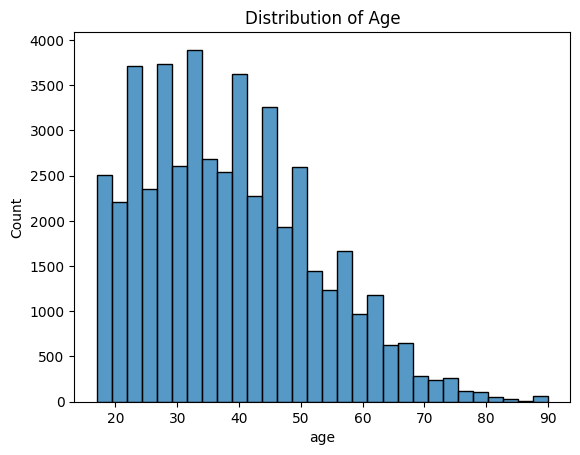

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['age'], bins=30)
plt.title("Distribution of Age")
plt.show()

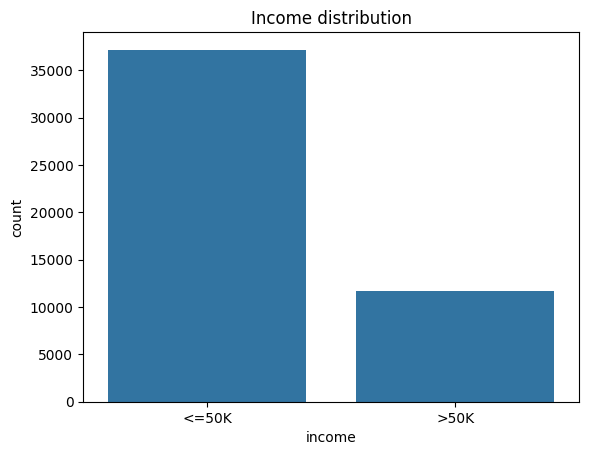

In [3]:
sns.countplot(x='income', data=df)
plt.title("Income distribution")
plt.show()

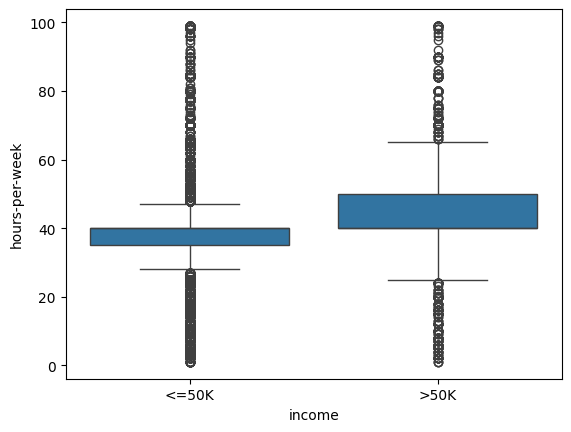

In [4]:
sns.boxplot(x='income', y='hours-per-week', data=df)
plt.show()

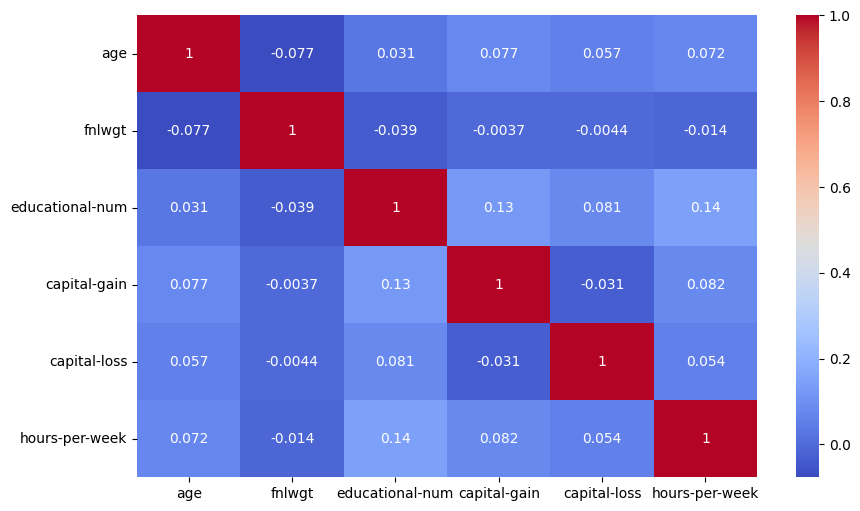

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [3]:
df = df.drop(columns=['fnlwgt','education']) #отстранување непотребни колони

In [4]:
df = df.drop(columns=['marital-status','relationship','race'])

In [5]:
df = df.replace('?', pd.NA)
df = df.dropna()

In [6]:
df = pd.get_dummies(df, drop_first=True) #претвора категоријални аттр. во бројки

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score

# поделба на тест и тренирачко множ.
X = df.drop("income_>50K", axis=1)
y = df["income_>50K"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# тренирање со наивен баесов клас.
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

#LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
lda_pred = lda.predict(X_test)

#QDA
qda = QuadraticDiscriminantAnalysis(reg_param=0.01)
qda.fit(X_train, y_train)
qda_pred = qda.predict(X_test)

# споредба на точност
print("Naive Bayes accuracy:", accuracy_score(y_test, nb_pred))
print("LDA accuracy:", accuracy_score(y_test, lda_pred))
print("QDA accuracy:", accuracy_score(y_test, qda_pred))

Naive Bayes accuracy: 0.8046434494195688
LDA accuracy: 0.81934770591487
QDA accuracy: 0.8016583747927032
